Earring    | Diameter (px)   | Real Size (mm) 
---------------------------------------------
#1         | 382.0           | 74.80          
#2         | 382.0           | 74.80          


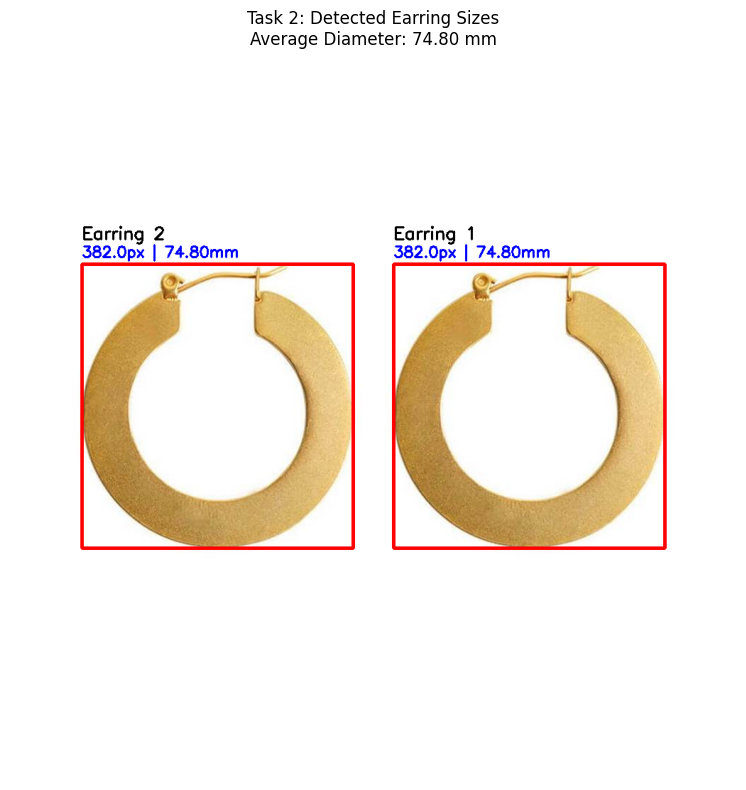

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_real_size_mm(pixel_width):
    """
    Applies camera geometry:
    f = 8mm, u = 720mm, pixel_size = 0.0022mm
    M = (f / (u - f)) = 8 / 712 = 1/89
    Real Size = (pixels * pixel_size) / M
    """
    f = 8.0
    u = 720.0
    pixel_size = 0.0022
    
    # Magnification M = v/u where v = (f*u)/(u-f)
    # This simplifies to M = f / (u - f)
    magnification = f / (u - f)
    
    sensor_size_mm = pixel_width * pixel_size
    real_size_mm = sensor_size_mm / magnification
    return real_size_mm

# 1. Load Image
img_path = 'media\\earrings.jpg'
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    print(f"Error: Could not find image at {img_path}")
    exit()

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2. Thresholding (Using your proven logic)
_, binary = cv2.threshold(img_gray, 240, 255, cv2.THRESH_BINARY_INV)

# 3. Find Contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_img = img_bgr.copy()
measurements = []

print(f"{'Earring':<10} | {'Diameter (px)':<15} | {'Real Size (mm)':<15}")
print("-" * 45)

count = 0
for cnt in contours:
    # Get bounding box
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter for the two main earrings (ignoring small noise)
    if w > 100: 
        count += 1
        
        # Diameter in pixels is approximated by the width of the bounding box
        diameter_px = float(w)
        
        # Calculate real-world size
        size_mm = get_real_size_mm(diameter_px)
        measurements.append(size_mm)
        
        # Draw Bounding Box (Red)
        cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 0, 255), 3)
        
        # Draw Label on image
        label_top = f"Earring {count}"
        label_bot = f"{diameter_px:.1f}px | {size_mm:.2f}mm"
        
        cv2.putText(output_img, label_top, (x, y - 35), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
        cv2.putText(output_img, label_bot, (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
        print(f"#{count:<9} | {diameter_px:<15.1f} | {size_mm:<15.2f}")

# 4. Visualization
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title(f"Task 2: Detected Earring Sizes\nAverage Diameter: {np.mean(measurements):.2f} mm")
plt.axis('off')
plt.tight_layout()
plt.show()